In [1]:
import tensorflow as tf

from tensorflow.lite.experimental.microfrontend.python.ops import audio_microfrontend_op as frontend_op
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.platform import gfile

import tensorflow_model_optimization as tfmot

import functools

import matplotlib.pyplot as plt
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import seaborn as sns
import os, pickle, sys, time
import shutil
import json
from scipy.io import  wavfile
from IPython import display

import cmsisdsp as dsp
import cmsisdsp.fixedpoint as f

In [2]:
# test_wav_file = '/Users/jeremy/data/speech_commands_v0.02/forward/6aa8def4_nohash_1.wav'
test_wav_file   = '/Users/jeremy/data/speech_commands_v0.02/marvin/5744b6a7_nohash_1.wav'

In [3]:
def get_lfbe_func(data_config):
  """
  Returns a TF graph as a function that converts an audio waveform into log Mel filterbank energies.
  The returned function takes wave tensor input and returns a spectrogram tensor output.

  data_config                      :  Data configuration, returned by get_data_config()
  """
  # building a TF graph here, but do not use tf.function, because the
  # if statements should be evaluated at graph construction time, not evaluation time
  def lfbe_func(next_element):
    audio_wav = tf.cast(next_element, tf.float32)
      
    # apply preemphasis
    preemphasis_coef = 1 - 2 ** -5
    power_offset = 52
    num_mel_bins = data_config['dct_coefficient_count']
    paddings = tf.constant([[0, 0], [1, 0]])
    # for some reason, tf.pad only works with the extra batch dimension, but then we remove it after pad
    audio_wav = tf.expand_dims(audio_wav, 0)
    audio_wav = tf.pad(tensor=audio_wav, paddings=paddings, mode='CONSTANT')
    audio_wav = audio_wav[:, 1:] - preemphasis_coef * audio_wav[:, :-1]
    audio_wav = tf.squeeze(audio_wav)
    
    stfts = tf.signal.stft(audio_wav,  frame_length=data_config['window_size_samples'], 
                            frame_step=data_config['window_stride_samples'], fft_length=None,
                            window_fn=functools.partial(
                              tf.signal.hamming_window, periodic=False),
                            pad_end=False,
                            name='STFT')
  
    # compute magnitude spectrum [batch_size, num_frames, NFFT]
    magspec = tf.abs(stfts)
    num_spectrogram_bins = magspec.shape[-1]
  
    # compute power spectrum [num_frames, NFFT]
    powspec = (1 / data_config['window_size_samples']) * tf.square(magspec)
    powspec_max = tf.reduce_max(input_tensor=powspec)
    powspec = tf.clip_by_value(powspec, 1e-30, powspec_max) # prevent -infinity on log
  
    def log10(x):
      # Compute log base 10 on the tensorflow graph.
      # x is a tensor.  returns log10(x) as a tensor
      numerator = tf.math.log(x)
      denominator = tf.math.log(tf.constant(10, dtype=numerator.dtype))
      return numerator / denominator
  
    # Warp the linear-scale, magnitude spectrograms into the mel-scale.
    lower_edge_hertz, upper_edge_hertz = 0.0, data_config['sample_rate'] / 2.0
    linear_to_mel_weight_matrix = (
        tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=num_mel_bins,
            num_spectrogram_bins=num_spectrogram_bins,
            sample_rate=data_config['sample_rate'],
            lower_edge_hertz=lower_edge_hertz,
            upper_edge_hertz=upper_edge_hertz))

    mel_spectrograms = tf.tensordot(powspec, linear_to_mel_weight_matrix,1)
    mel_spectrograms.set_shape(magspec.shape[:-1].concatenate(
        linear_to_mel_weight_matrix.shape[-1:]))

    log_mel_spec = 10 * log10(mel_spectrograms)
    log_mel_spec = tf.expand_dims(log_mel_spec, -2, name="mel_spec")

    log_mel_spec = (log_mel_spec + power_offset - 32 + 32.0) / 64.0
    log_mel_spec = tf.clip_by_value(log_mel_spec, 0, 1)
      
    return log_mel_spec
  
  return lfbe_func

In [4]:
data_config = {'sample_rate': 16000,
               'clip_duration_ms': 1000,
               'window_size_ms': 64.0,
               'window_stride_ms': 32.0,
               'dct_coefficient_count': 40,
               'desired_samples': 16000,
               'window_size_samples': 1024,
               'window_stride_samples': 512,
               'spectrogram_length': 30,
               'num_samples': -1,
          }

array([  101,   142,   145,    60,    23,    63,    25, 65461])

In [6]:
lfbe_func = get_lfbe_func(data_config)


In [7]:
# to convert the wav file to a simple binary file:
# sox ~/data/speech_commands_v0.02/marvin/5744b6a7_nohash_1.wav -b 16 -e signed-integer -r 16000 5744b6a7_nohash_1.raw

# test_wav_file = '/Users/jeremy/data/speech_commands_v0.02/forward/6aa8def4_nohash_1.wav'
# test_wav_file = '/Users/jeremy/data/speech_commands_v0.02/forward/24a3e589_nohash_2.wav'
# test_wav_file = '/Users/jeremy/data/speech_commands_v0.02/marvin/8353fea1_nohash_0.wav'
test_wav_file = '/Users/jeremy/data/speech_commands_v0.02/marvin/5744b6a7_nohash_1.wav'
 

# Read the WAV file
fs, test_wav = wavfile.read(test_wav_file)
# test_wav = test_wav/np.max(np.abs(test_wav))
print("Sample Rate:", fs)
print("Data[:10]:", test_wav[:10])
print(f"Range = [{np.min(test_wav)}:{np.max(test_wav)}]")

Sample Rate: 16000
Data[:10]: [101 142 145  60  23  63  25 -75 -58 -11]
Range = [-3494:7889]


In [8]:
specgram = lfbe_func(test_wav)
print(f"Shape = {specgram.shape}")

2024-12-04 08:02:36.279640: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-12-04 08:02:36.279679: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-12-04 08:02:36.279691: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-12-04 08:02:36.279728: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-12-04 08:02:36.279751: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Shape = (30, 1, 40)


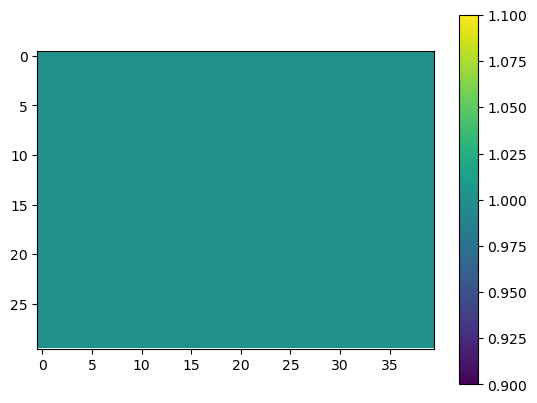

In [9]:
plt.imshow(np.squeeze(specgram))
plt.colorbar()

In [15]:


winlen  = data_config['window_size_samples']
winstep = data_config['window_stride_samples']


# Define the padding and preemphasis coefficient
paddings = (1,0)
preemphasis_coef = 0.97  # Adjust this as needed
# Add padding to account for what's lost in preemphasis filter
test_wav_emph = np.pad(test_wav, paddings, mode='constant')
test_wav_emph = test_wav[1:] - preemphasis_coef * test_wav[:-1]  # Apply preemphasis

slices = sliding_window_view(test_wav_emph, winlen)[0::winstep,:]

win_hamming_f32 = dsp.arm_hanning_f32(winlen)


rfftf32=dsp.arm_rfft_fast_instance_f32()
status=dsp.arm_rfft_fast_init_f32(rfftf32,len(win_hamming_f32))

for i in range(slices.shape[0]):
  sig_slice = slices[i,:]
  sig_slice = sig_slice*win_hamming_f32
  result = dsp.arm_rfft_fast_init_f32(rfftf32,sig_slice)
  break

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:


t = np.arange(1000)/16000
sig = np.sin(2*3.14159*500*t)
result = dsp.arm_rfft_fast_f32(rfftf32,sig,0)

ff = np.linspace(0,8000,len(result))

In [ ]:
n = 10
plt.plot(ff[:n], np.abs(result[:n]))

In [ ]:
    # stfts = tf.signal.stft(audio_wav,  frame_length=data_config['window_size_samples'], 
    #                         frame_step=data_config['window_stride_samples'], fft_length=None,
    #                         window_fn=functools.partial(
    #                           tf.signal.hamming_window, periodic=False),
    #                         pad_end=False,
    #                         name='STFT')
  
    # # compute magnitude spectrum [batch_size, num_frames, NFFT]
    # magspec = tf.abs(stfts)
    # num_spectrogram_bins = magspec.shape[-1]
  
    # # compute power spectrum [num_frames, NFFT]
    # powspec = (1 / data_config['window_size_samples']) * tf.square(magspec)
    # powspec_max = tf.reduce_max(input_tensor=powspec)
    # powspec = tf.clip_by_value(powspec, 1e-30, powspec_max) # prevent -infinity on log
  
    # def log10(x):
    #   # Compute log base 10 on the tensorflow graph.
    #   # x is a tensor.  returns log10(x) as a tensor
    #   numerator = tf.math.log(x)
    #   denominator = tf.math.log(tf.constant(10, dtype=numerator.dtype))
    #   return numerator / denominator
  
    # # Warp the linear-scale, magnitude spectrograms into the mel-scale.
    # lower_edge_hertz, upper_edge_hertz = 0.0, data_config['sample_rate'] / 2.0
    # linear_to_mel_weight_matrix = (
    #     tf.signal.linear_to_mel_weight_matrix(
    #         num_mel_bins=num_mel_bins,
    #         num_spectrogram_bins=num_spectrogram_bins,
    #         sample_rate=data_config['sample_rate'],
    #         lower_edge_hertz=lower_edge_hertz,
    #         upper_edge_hertz=upper_edge_hertz))

    # mel_spectrograms = tf.tensordot(powspec, linear_to_mel_weight_matrix,1)
    # mel_spectrograms.set_shape(magspec.shape[:-1].concatenate(
    #     linear_to_mel_weight_matrix.shape[-1:]))

    # log_mel_spec = 10 * log10(mel_spectrograms)
    # log_mel_spec = tf.expand_dims(log_mel_spec, -2, name="mel_spec")

    # log_mel_spec = (log_mel_spec + power_offset - 32 + 32.0) / 64.0
    # log_mel_spec = tf.clip_by_value(log_mel_spec, 0, 1)